<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>K-Means Clustering on Real-World Data</b>
</h1>
<div style="font-family:'Times New Roman';">
<b>Goal:</b>
<ol>
<li>Apply K-Means using scikit-learn on a real-world dataset.</li>
<li>Perform basic EDA and preprocessing (scaling) before clustering.</li>
<li>Use the Elbow Method to choose an appropriate value of K.</li>
<li>Visualize and interpret the resulting clusters.</li>
</ol>
In the previous notebooks, I built intuition for K-Means and implemented 
it from scratch on synthetic data. Now, I'll use scikit-learn's 
implementation on a real dataset to see how clustering works in practice 
- and what these clusters might actually <i>mean</i>.
</div>

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

In [2]:
# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Display first 5 rows
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# Select Annual Income and Spending Score
X = df.iloc[:, [3, 4]].values

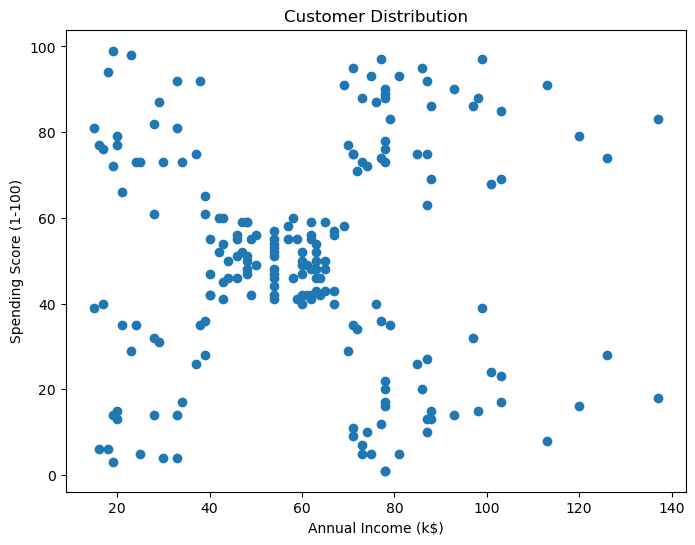

In [4]:
# Plot dataset
plt.figure(figsize=(8,6))

plt.scatter(X[:, 0], X[:, 1])

# Graph labels
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Distribution")

plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Finding the Optimal Number of Clusters Using the Elbow Method</b>
</h2>
<div style="font-family:'Times New Roman';">
Just like in the from-scratch notebook, I don't know the right 
number of clusters for this real data in advance. So I'll use the 
<b>Elbow Method</b> again running K-Means for a range of K values 
and plotting K vs <b>inertia (WCSS)</b> to look for the "elbow" 
point where adding more clusters stops giving meaningful improvement.
</div>

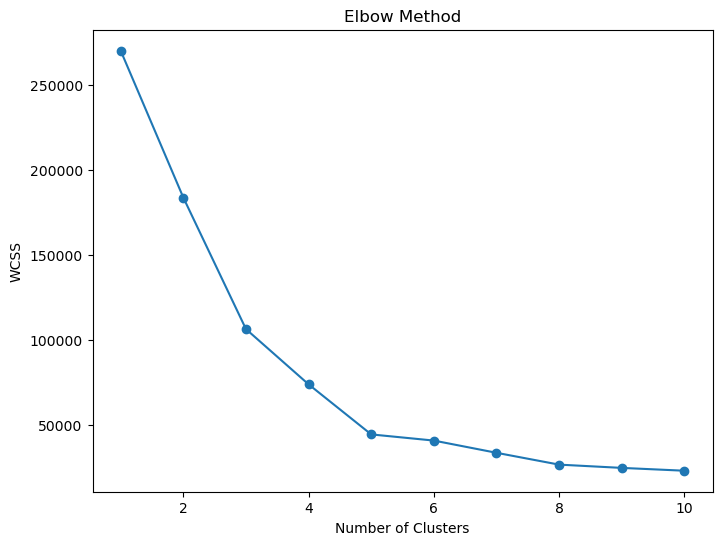

In [5]:
# Store WCSS values
wcss = []

# Run K-Means for different values of k
for i in range(1, 11):

    kmeans = KMeans(n_clusters=i, random_state=42)

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure(figsize=(8,6))

plt.plot(range(1, 11), wcss, marker='o')

# Graph labels
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Applying K-Means Clustering</b>
</h2>
<div style="font-family:'Times New Roman';">
Based on the elbow plot, I'll now pick a value of K and fit the 
final K-Means model on the data. This will assign every data point 
to one of the K clusters, which we can then analyze and visualize.
</div>

In [6]:
# Apply K-Means with optimal clusters
kmeans = KMeans(n_clusters=5, random_state=42)

# Predict cluster labels
y_kmeans = kmeans.fit_predict(X)

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Visualizing Clusters</b>
</h2>

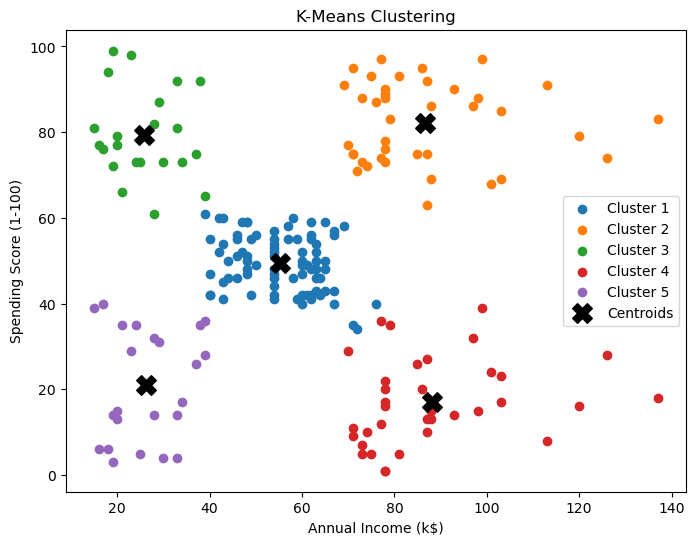

In [7]:
# Plot clusters
plt.figure(figsize=(8,6))

plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], label='Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], label='Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], label='Cluster 3')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], label='Cluster 4')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], label='Cluster 5')

# Plot centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=200,
    marker='X',
    color='black',
    label='Centroids'
)

# Graph labels
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("K-Means Clustering")

plt.legend()
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Result</b>
</h2>
<div style="font-family:'Times New Roman';">
K-Means Clustering was successfully implemented using the 
<b>scikit-learn</b> library, and the <b>Elbow Method</b> was used 
to determine an appropriate number of clusters for the data.
</div>

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Conclusion</b>
</h2>
<div style="font-family:'Times New Roman';">
This experiment demonstrated <b>customer segmentation</b> using 
K-Means Clustering, along with visualization of the resulting 
clusters and analysis of their centroids. By grouping similar 
customers together, this kind of analysis can help businesses 
understand different customer segments and tailor strategies 
(like marketing or recommendations) accordingly.
</div>